# 03 · Train the contrastive-learning model

Encoder and projector MLPs trained with the **Weinberger loss**: all views
(v1 and v2, i.e. different C) of one cosmology are pulled together, different cosmologies pushed apart.
Hyperparameters and architecture: `config.CL`. The model with the lowest validation loss is kept.

Reads `data/<run>/pk/{train,val}_v{1,2}.npz`. Writes `outputs/<run>/cl/model.pt`, `history.json`, `loss.png`
and the standardised latents of every set to `data/<run>/latents/`. Next: `04_evaluate_CL.ipynb`.

In [1]:
import config as cfg
from clmini import data, cl, sbi_tools, metrics, plots
print(f"run = {cfg.RUN_NAME} | data -> {cfg.DATA_DIR.relative_to(cfg.ROOT)} | outputs -> {cfg.OUT_DIR.relative_to(cfg.ROOT)}")
cfg.CL

run = full | data -> data/full | outputs -> outputs/full


{'hidden_encoder': [48, 32, 24],
 'dim_latent': 2,
 'hidden_projector': [24, 24, 32],
 'dim_projection': 32,
 'n_epochs': 10,
 'n_batches_per_epoch': 64,
 'batch_size': 1024,
 'lr': 0.005,
 'weight_decay': 1e-08,
 'clip_grad_norm': 10.0,
 'val_batch_fraction': 0.16666666666666666,
 'loss': {'delta_pull': 0.5,
  'delta_push': 1.5,
  'c_pull': 1.0,
  'c_push': 1.0,
  'c_reg': 0.001}}

In [2]:
history = cl.train_cl(cfg)

epoch   1/10  train 1.7851  val 2.0629
epoch   2/10  train 1.5139  val 1.9653
epoch   3/10  train 1.6369  val 2.2124
epoch   4/10  train 1.4972  val 2.1425
epoch   5/10  train 1.4669  val 2.1580
epoch   6/10  train 1.4481  val 2.1894
epoch   7/10  train 1.3868  val 2.1193
epoch   8/10  train 1.3806  val 2.3095
epoch   9/10  train 1.5628  val 2.3563
epoch  10/10  train 1.3695  val 2.2532


PosixPath('outputs/full/cl/loss.png')

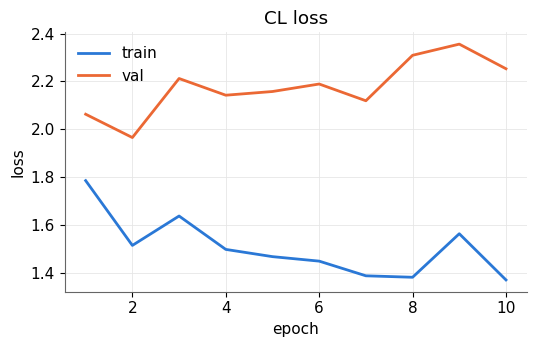

In [3]:
fig = plots.loss_history(history); metrics.save_fig(cfg, fig, "cl/loss")

## Encode all datasets with the best model

In [4]:
cl.export_latents(cfg)

latents saved to data/full/latents
